# Graph neural network approach including species interactions to predict invasion risk

## Load dependencies

In [23]:
import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, SAGEConv
from tqdm.auto import tqdm
from pygbif import species as gbif_species
from pygbif import occurrences
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

## 1. Load & standardize data

In [2]:
# ==============================================================================
# 1. DATA LOADING AND STANDARDIZATION
# ==============================================================================
repo_root = Path.cwd().parent
sinas_path = repo_root / 'data' / 'sinas_matched_species.csv'
network_path = repo_root / 'data' / 'matched_globi_network.csv'
country_col = 'location'
 
print("📖 Reading repository datasets...")
df_sinas = pd.read_csv(sinas_path)
df_net = pd.read_csv(network_path)
 
# Ensure ID formatting
df_sinas = df_sinas.dropna(subset=['gbif_id']).copy()
df_sinas['gbif_id'] = df_sinas['gbif_id'].astype(int)
 
df_sinas['is_native'] = df_sinas['establishmentMeans'].fillna('').str.lower().str.contains('native')
df_sinas['is_alien']  = df_sinas['establishmentMeans'].fillna('').str.lower().str.contains('introduced|invasive|naturalised|alien')

📖 Reading repository datasets...


## 2. Creating graph based dataset

In [3]:
# ==============================================================================
# 2. BUILDING INDEX MAPPING DICTIONARIES
# ==============================================================================
print("⚙️ Engineering continuous tensor index maps...")
 
# Gather the complete universe of unique species across both files
sinas_sp    = set(df_sinas['gbif_id'].unique())
net_src_sp  = set(df_net['source_gbif_id'].dropna().astype(int).unique())
net_tgt_sp  = set(df_net['target_gbif_id'].dropna().astype(int).unique())
all_species_ids = sorted(list(sinas_sp | net_src_sp | net_tgt_sp))
 
all_country_names = sorted(list(df_sinas[country_col].dropna().unique()))
 
sp_to_idx = {sp_id: idx for idx, sp_id in enumerate(all_species_ids)}
idx_to_sp = {idx: sp_id for sp_id, idx in sp_to_idx.items()}
 
co_to_idx = {name: idx for idx, name in enumerate(all_country_names)}
idx_to_co = {idx: name for name, idx in co_to_idx.items()}
 
num_species  = len(all_species_ids)
num_countries = len(all_country_names)
embedding_dim = 32
 
# Pre-build species ID -> taxon name lookup once (reused in inference)
id_to_name = df_sinas.drop_duplicates('gbif_id').set_index('gbif_id')['taxon'].to_dict()
 
print(f"   Total Unique Graph Nodes ➔ Species: {num_species} | Countries: {num_countries}")

⚙️ Engineering continuous tensor index maps...
   Total Unique Graph Nodes ➔ Species: 220423 | Countries: 289


## 3. Group GLOBI lexicon to classes

In [4]:
# ==============================================================================
# 3. INTERACTION TYPE ONTOLOGY (COMPREHENSIVE GLOBI VOCABULARY)
# ==============================================================================

# Bottom-Up Support: The actor acts as a consumer/predator/parasite of the target
CONSUMPTION_TERMS = {
    'eats', 'preysOn', 'parasitizes', 'pathogenOf', 'parasitoidOf', 'consumes',
    'endoparasitoidOf', 'ectoparasitoidOf', 'endoparasiteOf', 'ectoparasiteOf',
    'scavenges', 'browses', 'grazesOn', 'hasHost', 'kills', 'saprophyteOf',
    'hyperparasiteOf', 'hyperparasitoidOf', 'bloodFeedsOn', 'nectarFeedsOn',
    'pollenFeedsOn', 'seedEaterOf', 'woodBorerOf', 'leafMinerOf', 'gallMakerOf',
    'defoliatorOf', 'rootFeederOf', 'vectorOf'
}

# Positive Facilitation: Cooperative, symbiotic, or mutually beneficial associations
MUTUALISM_TERMS = {
    'pollinates', 'visitsFlowersOf', 'symbiontOf', 'mutualistOf', 'associatedWith', 
    'coOccursWith', 'hasSymbiont', 'commensalistOf', 'hasCommensalist', 'epiphyteOf', 
    'hasEpiphyte', 'inquilineOf', 'hasInquiline', 'phoreticOf', 'hasPhoretic', 
    'mycorrhizalWith', 'dispersesSeedsOf', 'disperses', 'vectorFor', 'sheltersWithin', 
    'providesShelterTo', 'nestedIn', 'hostsNestedIn', 'flowersVisitedBy', 'visitedBy'
}

# Negative Co-occurrence: Direct resource locking, displacement, or chemical defense
COMPETITION_TERMS = {
    'competesWith', 'interferesWith', 'allelopathicTo', 'inhibits', 'displaces', 
    'antagonistOf', 'interferesWith'
}

# Top-Down Pressure: The actor is the victim/host; the target acts as its predator/parasite
VICTIM_TERMS = {
    'hostOf', 'hasParasite', 'hasPathogen', 'hasParasitoid', 'preyedOnBy', 'eatenBy',
    'parasitizedBy', 'infectedBy', 'killedBy', 'preyedUponBy', 'parasitoidBy', 'pathogenBy'
}

def categorize_interaction(itype: str) -> str:
    if pd.isna(itype):
        return 'mutualism'
        
    itype_clean = itype.strip()
    itype_lower = itype_clean.lower()
    
    # Precise hash-set matching for direct GloBI OBO terms
    if itype_clean in CONSUMPTION_TERMS: return 'resource'
    if itype_clean in MUTUALISM_TERMS:   return 'mutualism'
    if itype_clean in COMPETITION_TERMS: return 'competition'
    if itype_clean in VICTIM_TERMS:      return 'enemy'
    
    # Substring fallback parsing for custom or unvetted text inputs
    if 'by' in itype_lower and any(w in itype_lower for w in ['eat', 'prey', 'parasit', 'kill', 'infect', 'attack']): 
        return 'enemy'
    if any(w in itype_lower for w in ['eat', 'prey', 'consume', 'host', 'feed', 'graze', 'browse', 'destroy']): 
        return 'resource'
    if any(w in itype_lower for w in ['symbio', 'mutual', 'pollin', 'cooccur', 'visit', 'associat', 'commens', 'shelter']): 
        return 'mutualism'
    if any(w in itype_lower for w in ['compet', 'inhib', 'displac', 'antagon', 'resist', 'exclude']): 
        return 'competition'
        
    return 'mutualism'

# Compute vocabulary array mapping
unique_types = df_net['interaction_type'].dropna().unique()
interaction_mapping = {itype: categorize_interaction(itype) for itype in unique_types}

## 4. Create the knowledge graph

In [30]:
# ==============================================================================
# 4. ASSEMBLING THE HETERODATA ECOLOGICAL KNOWLEDGE GRAPH
# ==============================================================================
print("🕸️ Compiling tensors into a PyTorch Geometric Graph Network...")
data = HeteroData()

torch.manual_seed(42)
data['species'].x = torch.randn(num_species, embedding_dim)
data['country'].x = torch.randn(num_countries, embedding_dim)

# ---- Geographic edges (SInAS) ----
df_sinas['sp_idx'] = df_sinas['gbif_id'].map(sp_to_idx)
df_sinas['co_idx'] = df_sinas[country_col].map(co_to_idx)

native_df = df_sinas[df_sinas['is_native']].dropna(subset=['sp_idx', 'co_idx'])
alien_df  = df_sinas[df_sinas['is_alien']].dropna(subset=['sp_idx', 'co_idx'])

data['species', 'native_to', 'country'].edge_index = torch.tensor(
    np.array([native_df['sp_idx'].values, native_df['co_idx'].values]),
    dtype=torch.long
)
data['species', 'established_in', 'country'].edge_index = torch.tensor(
    np.array([alien_df['sp_idx'].values, alien_df['co_idx'].values]),
    dtype=torch.long
)

# ---- Biotic / trophic edges (GloBI) ----
df_net_clean = df_net.dropna(subset=['interaction_type', 'source_gbif_id', 'target_gbif_id']).copy()
df_net_clean['src_idx'] = df_net_clean['source_gbif_id'].astype(int).map(sp_to_idx)
df_net_clean['tgt_idx'] = df_net_clean['target_gbif_id'].astype(int).map(sp_to_idx)
df_net_clean = df_net_clean.dropna(subset=['src_idx', 'tgt_idx'])
df_net_clean['category'] = df_net_clean['interaction_type'].map(interaction_mapping)

# Loop handles baseline channels (excluding enemy)
for cat in ['resource', 'mutualism', 'competition']:
    sub_df = df_net_clean[df_net_clean['category'] == cat]
    data['species', cat, 'species'].edge_index = torch.tensor(
        np.array([sub_df['src_idx'].values, sub_df['tgt_idx'].values]),
        dtype=torch.long
    )

# ---- Combined Enemy Lane Compilation ----
# Track 1: Isolate original explicit enemy records from the ontology (if any exist)
enemy_df = df_net_clean[df_net_clean['category'] == 'enemy']
orig_src = enemy_df['src_idx'].values
orig_tgt = enemy_df['tgt_idx'].values

# Track 2: Isolate resource records and invert them to infer top-down pressure
res_df = df_net_clean[df_net_clean['category'] == 'resource']
flipped_src = res_df['tgt_idx'].values
flipped_tgt = res_df['src_idx'].values

# FIX: Concatenate both vectors end-to-end to preserve explicit data AND mirrored layers
combined_src = np.concatenate([orig_src, flipped_src])
combined_tgt = np.concatenate([orig_tgt, flipped_tgt])

data['species', 'enemy', 'species'].edge_index = torch.tensor(
    np.array([combined_src, combined_tgt]),
    dtype=torch.long
)

print(data)

🕸️ Compiling tensors into a PyTorch Geometric Graph Network...
HeteroData(
  species={ x=[220423, 32] },
  country={ x=[289, 32] },
  (species, native_to, country)={ edge_index=[2, 214474] },
  (species, established_in, country)={ edge_index=[2, 160034] },
  (species, resource, species)={ edge_index=[2, 5950919] },
  (species, mutualism, species)={ edge_index=[2, 2671830] },
  (species, competition, species)={ edge_index=[2, 0] },
  (species, enemy, species)={ edge_index=[2, 5950919] }
)


## 5. Define network architecture

In [32]:
# ==============================================================================
# 5. MODEL ARCHITECTURE
# ==============================================================================
CONV_SCHEMA = {
    ('species', 'resource', 'species'):       SAGEConv(embedding_dim, embedding_dim),
    ('species', 'mutualism', 'species'):      SAGEConv(embedding_dim, embedding_dim),
    ('species', 'competition', 'species'):    SAGEConv(embedding_dim, embedding_dim),
    ('species', 'enemy', 'species'):          SAGEConv(embedding_dim, embedding_dim),
    ('species', 'native_to', 'country'):      SAGEConv((embedding_dim, embedding_dim), embedding_dim),
    ('species', 'established_in', 'country'): SAGEConv((embedding_dim, embedding_dim), embedding_dim),
}
 
 
class RelationalEcologicalGNN(nn.Module):
    """
    Two-layer heterogeneous GraphSAGE encoder.
    Two message-passing steps let information propagate two hops:
    e.g. a predator's predator, or a species' native-range neighbours.
    """
    def __init__(self, dim: int, dropout: float = 0.3):
        super().__init__()
        conv_schema_1 = {
            ('species', 'resource', 'species'):       SAGEConv(dim, dim),
            ('species', 'mutualism', 'species'):      SAGEConv(dim, dim),
            ('species', 'competition', 'species'):    SAGEConv(dim, dim),
            ('species', 'enemy', 'species'):          SAGEConv(dim, dim),
            ('species', 'native_to', 'country'):      SAGEConv((dim, dim), dim),
            ('species', 'established_in', 'country'): SAGEConv((dim, dim), dim),
        }
        conv_schema_2 = {
            ('species', 'resource', 'species'):       SAGEConv(dim, dim),
            ('species', 'mutualism', 'species'):      SAGEConv(dim, dim),
            ('species', 'competition', 'species'):    SAGEConv(dim, dim),
            ('species', 'enemy', 'species'):          SAGEConv(dim, dim),
            ('species', 'native_to', 'country'):      SAGEConv((dim, dim), dim),
            ('species', 'established_in', 'country'): SAGEConv((dim, dim), dim),
        }
        self.conv1 = HeteroConv(conv_schema_1, aggr='mean')
        self.conv2 = HeteroConv(conv_schema_2, aggr='mean')
        self.dropout = nn.Dropout(p=dropout)
 
    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {k: self.dropout(F.gelu(v)) for k, v in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        return {k: F.gelu(v) for k, v in x_dict.items()}
 
 
class BioticLinkPredictor(nn.Module):
    """
    Bilinear dot-product scorer. Returns raw logits (no sigmoid) so that
    BCEWithLogitsLoss can be used for better numerical stability.
    """
    def __init__(self, dim: int):
        super().__init__()
        self.W = nn.Parameter(torch.randn(dim, dim) * 0.01)
 
    def forward(self, sp_emb, co_emb, sp_indices, co_indices):
        s = sp_emb[sp_indices]
        c = co_emb[co_indices]
        return torch.sum((s @ self.W) * c, dim=-1)   # raw logits

## 6. Train the model

In [33]:
# ==============================================================================
# 6. TRAINING
# ==============================================================================
print("\n🤖 Instantiating Graph Neural Network weights...")
torch.manual_seed(42)
encoder   = RelationalEcologicalGNN(dim=embedding_dim)
predictor = BioticLinkPredictor(dim=embedding_dim)

optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(predictor.parameters()), lr=0.01
)
criterion = nn.BCEWithLogitsLoss()

# Validation split: hold out 20% of positive edges
pos_edges = data['species', 'established_in', 'country'].edge_index
pos_sp    = pos_edges[0]
pos_co    = pos_edges[1]

n_pos  = pos_sp.size(0)
perm   = torch.randperm(n_pos)
n_val  = int(0.2 * n_pos)

val_sp,   val_co   = pos_sp[perm[:n_val]],  pos_co[perm[:n_val]]
train_sp, train_co = pos_sp[perm[n_val:]],  pos_co[perm[n_val:]]

# Scheduler and early stopping state — all outside the loop
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

best_val_loss      = float('inf')
patience_counter   = 0
EARLY_STOP_PATIENCE = 30

print("🏋️ Training Graph Neural Network...")

for epoch in range(1, 501):
    # --- Train ---
    encoder.train()
    predictor.train()
    optimizer.zero_grad()

    embeddings = encoder(data.x_dict, data.edge_index_dict)

    pos_preds = predictor(embeddings['species'], embeddings['country'], train_sp, train_co)

    neg_sp    = torch.randint(0, num_species,   (train_sp.size(0),), dtype=torch.long)
    neg_co    = torch.randint(0, num_countries, (train_co.size(0),), dtype=torch.long)
    neg_preds = predictor(embeddings['species'], embeddings['country'], neg_sp, neg_co)

    predictions = torch.cat([pos_preds, neg_preds])
    targets     = torch.cat([torch.ones(pos_preds.size(0)), torch.zeros(neg_preds.size(0))])

    loss = criterion(predictions, targets)
    loss.backward()
    optimizer.step()

    # --- Validate ---
    encoder.eval()
    predictor.eval()
    with torch.no_grad():
        emb        = encoder(data.x_dict, data.edge_index_dict)
        val_pos    = predictor(emb['species'], emb['country'], val_sp, val_co)
        val_neg_sp = torch.randint(0, num_species,   (val_sp.size(0),), dtype=torch.long)
        val_neg_co = torch.randint(0, num_countries, (val_co.size(0),), dtype=torch.long)
        val_neg    = predictor(emb['species'], emb['country'], val_neg_sp, val_neg_co)
        val_loss   = criterion(
            torch.cat([val_pos, val_neg]),
            torch.cat([torch.ones(val_sp.size(0)), torch.zeros(val_sp.size(0))])
        ).item()

    scheduler.step(val_loss)

    # --- Early stopping & checkpointing ---
    if val_loss < best_val_loss - 1e-4:
        best_val_loss  = val_loss
        patience_counter = 0
        torch.save({
            'encoder':   encoder.state_dict(),
            'predictor': predictor.state_dict(),
            'epoch':     epoch,
            'val_loss':  val_loss,
        }, 'best_eco_gnn.pt')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n⏹️  Early stopping at epoch {epoch} | Best Val Loss: {best_val_loss:.4f}")
            break

    del embeddings, emb, pos_preds, neg_preds, val_pos, val_neg
    torch.cuda.empty_cache()

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f"   Epoch {epoch:03d}/500 | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f} | LR: {lr:.5f}")

# Restore best weights from checkpoint
checkpoint = torch.load('best_eco_gnn.pt')
encoder.load_state_dict(checkpoint['encoder'])
predictor.load_state_dict(checkpoint['predictor'])
print(f"\n✅ Restored best weights from epoch {checkpoint['epoch']} | Val Loss: {checkpoint['val_loss']:.4f}")


🤖 Instantiating Graph Neural Network weights...
🏋️ Training Graph Neural Network...
   Epoch 001/500 | Train Loss: 0.6932 | Val Loss: 0.6929 | LR: 0.01000
   Epoch 010/500 | Train Loss: 0.5001 | Val Loss: 0.4338 | LR: 0.01000
   Epoch 020/500 | Train Loss: 0.3556 | Val Loss: 0.3313 | LR: 0.01000
   Epoch 030/500 | Train Loss: 0.3135 | Val Loss: 0.2993 | LR: 0.01000
   Epoch 040/500 | Train Loss: 0.2996 | Val Loss: 0.2829 | LR: 0.01000
   Epoch 050/500 | Train Loss: 0.2898 | Val Loss: 0.2751 | LR: 0.01000
   Epoch 060/500 | Train Loss: 0.2792 | Val Loss: 0.2638 | LR: 0.01000
   Epoch 070/500 | Train Loss: 0.2719 | Val Loss: 0.2591 | LR: 0.01000
   Epoch 080/500 | Train Loss: 0.2637 | Val Loss: 0.2541 | LR: 0.01000
   Epoch 090/500 | Train Loss: 0.2628 | Val Loss: 0.2452 | LR: 0.01000
   Epoch 100/500 | Train Loss: 0.2563 | Val Loss: 0.2424 | LR: 0.01000
   Epoch 110/500 | Train Loss: 0.2535 | Val Loss: 0.2366 | LR: 0.01000
   Epoch 120/500 | Train Loss: 0.2485 | Val Loss: 0.2354 | LR: 

# 7. Define how to perform risk prediction from the trained network

In [34]:
# ==============================================================================
# 7. INFERENCE — HORIZON SCANNING
# ==============================================================================
INFERENCE_CHUNK = 2048


def execute_gnn_horizon_scan(target_country_name: str, top_n: int = 500) -> pd.DataFrame:
    """
    Score every species not locally recorded in target_country_name using the
    trained GNN. Returns the top_n candidates ranked by invasion probability.
    top_n should be generous (e.g. 500) so the downstream GBIF validator has
    enough candidates to filter down to the final verified shortlist.
    """
    if target_country_name not in co_to_idx:
        raise ValueError(f"❌ '{target_country_name}' is not in the spatial index.")

    encoder.eval()
    predictor.eval()

    with torch.no_grad():
        final_embeddings = encoder(data.x_dict, data.edge_index_dict)

    co_idx = co_to_idx[target_country_name]

    # Block species already recorded in the target country (native OR alien)
    local_sp_ids     = df_sinas[df_sinas[country_col] == target_country_name]['gbif_id'].unique()
    local_sp_indices = {sp_to_idx[sp_id] for sp_id in local_sp_ids if sp_id in sp_to_idx}

    candidate_indices = [idx for idx in range(num_species) if idx not in local_sp_indices]
    candidate_tensor  = torch.tensor(candidate_indices, dtype=torch.long)
    country_tensor    = torch.full((len(candidate_indices),), co_idx, dtype=torch.long)

    # Chunked inference
    scores = []
    with torch.no_grad():
        for i in range(0, len(candidate_indices), INFERENCE_CHUNK):
            chunk_sp = candidate_tensor[i : i + INFERENCE_CHUNK]
            chunk_co = country_tensor[i : i + INFERENCE_CHUNK]
            logits   = predictor(
                final_embeddings['species'], final_embeddings['country'],
                chunk_sp, chunk_co
            )
            scores.append(torch.sigmoid(logits))

    risk_probabilities = torch.cat(scores).numpy()

    results = [
        {
            'gbif_id':                  idx_to_sp[idx],
            'taxon_name':               id_to_name.get(idx_to_sp[idx], f"GBIF:{idx_to_sp[idx]}"),
            'gnn_invasion_probability': float(prob),
        }
        for idx, prob in zip(candidate_indices, risk_probabilities)
    ]

    df_scan = (
        pd.DataFrame(results)
        .sort_values('gnn_invasion_probability', ascending=False)
        .reset_index(drop=True)
        .head(top_n)
    )
    print(f"✅ GNN scan complete — {len(df_scan)} candidates ranked for GBIF validation.")
    return df_scan


📊 GRAPH NEURAL NETWORK VERIFICATION REPORT
✅ ROC-AUC Score: 0.9675  (Target: > 0.80 for strong ranking)
✅ PR-AUC Score:  0.9611  (Target: > 0.80 for low false-alarms)
ℹ️ True Invasion (Pos) Risk Range: 0.0002 to 0.9994
ℹ️ True Absence  (Neg) Risk Range: 0.0000 to 0.9969


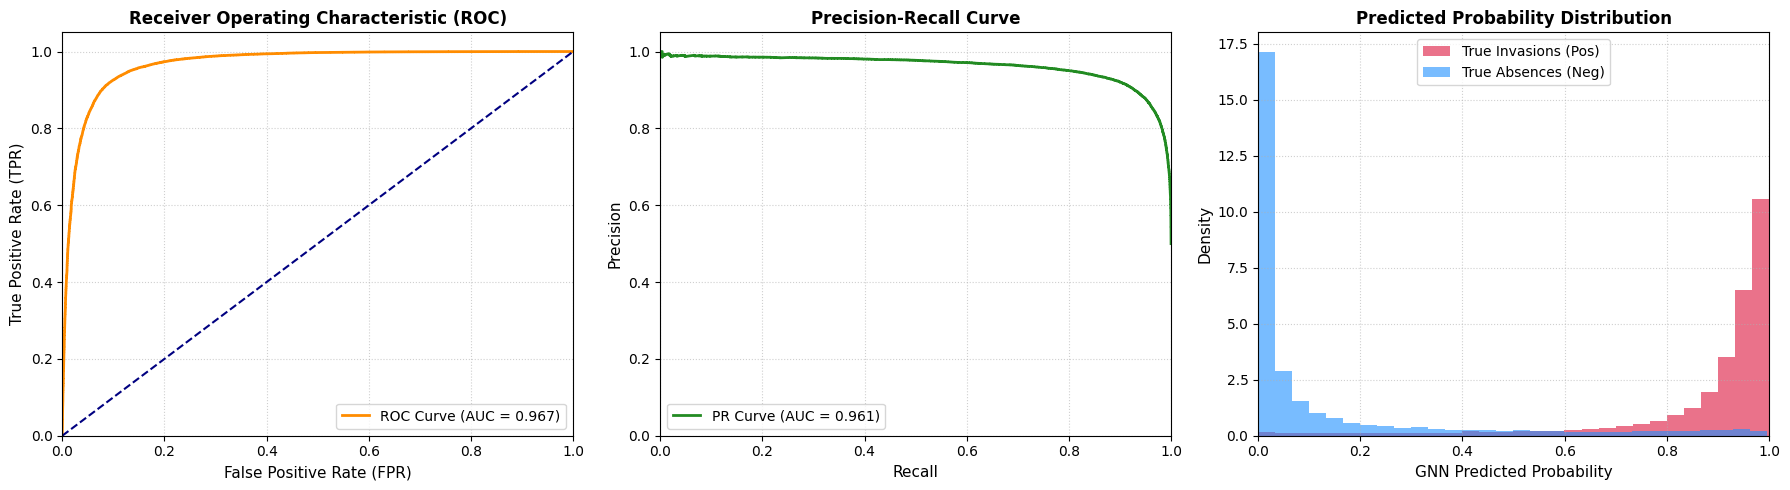


Final ROC-AUC: 0.9675
Final PR-AUC:  0.9611


In [35]:
# Evaluation and plotting function for performance metrics and diagnostic visualization

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import auc, precision_recall_curve, roc_curve


def evaluate_and_plot_performance(
    encoder,
    predictor,
    data,
    val_sp,
    val_co,
    val_neg_sp,
    val_neg_co
):
    """
    Computes core link prediction metrics and displays a 3-panel
    diagnostic dashboard to visually verify GNN classification performance.
    """

    encoder.eval()
    predictor.eval()

    with torch.no_grad():

        # 1. Generate network embeddings from the validation state
        emb = encoder(data.x_dict, data.edge_index_dict)

        # 2. Extract raw model outputs for both positive and negative validation edges
        val_pos_logits = predictor(
            emb['species'],
            emb['country'],
            val_sp,
            val_co
        )

        val_neg_logits = predictor(
            emb['species'],
            emb['country'],
            val_neg_sp,
            val_neg_co
        )

        # 3. Convert logits to probabilities
        pos_probs = torch.sigmoid(val_pos_logits).cpu().numpy()
        neg_probs = torch.sigmoid(val_neg_logits).cpu().numpy()

    # ------------------------------------------------------------------
    # BUILD GROUND TRUTH LABELS
    # ------------------------------------------------------------------
    y_true = np.concatenate([
        np.ones(len(pos_probs)),
        np.zeros(len(neg_probs))
    ])

    y_scores = np.concatenate([
        pos_probs,
        neg_probs
    ])

    # ------------------------------------------------------------------
    # ROC CURVE
    # ------------------------------------------------------------------
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    # ------------------------------------------------------------------
    # PRECISION-RECALL CURVE
    # ------------------------------------------------------------------
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)

    # ------------------------------------------------------------------
    # TERMINAL REPORT
    # ------------------------------------------------------------------
    print("\n📊 GRAPH NEURAL NETWORK VERIFICATION REPORT")
    print("=" * 55)
    print(f"✅ ROC-AUC Score: {roc_auc:.4f}  (Target: > 0.80 for strong ranking)")
    print(f"✅ PR-AUC Score:  {pr_auc:.4f}  (Target: > 0.80 for low false-alarms)")
    print("=" * 55)
    print(
        f"ℹ️ True Invasion (Pos) Risk Range: "
        f"{pos_probs.min():.4f} to {pos_probs.max():.4f}"
    )
    print(
        f"ℹ️ True Absence  (Neg) Risk Range: "
        f"{neg_probs.min():.4f} to {neg_probs.max():.4f}"
    )

    # ------------------------------------------------------------------
    # MATPLOTLIB DASHBOARD
    # ------------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ==============================================================
    # PLOT A: ROC CURVE
    # ==============================================================
    axes[0].plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=f"ROC Curve (AUC = {roc_auc:.3f})"
    )

    axes[0].plot(
        [0, 1],
        [0, 1],
        color="navy",
        lw=1.5,
        linestyle="--"
    )

    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("False Positive Rate (FPR)", fontsize=11)
    axes[0].set_ylabel("True Positive Rate (TPR)", fontsize=11)
    axes[0].set_title(
        "Receiver Operating Characteristic (ROC)",
        fontsize=12,
        fontweight="bold"
    )
    axes[0].legend(loc="lower right", fontsize=10)
    axes[0].grid(True, linestyle=":", alpha=0.6)

    # ==============================================================
    # PLOT B: PRECISION-RECALL CURVE
    # ==============================================================
    axes[1].plot(
        recall,
        precision,
        color="forestgreen",
        lw=2,
        label=f"PR Curve (AUC = {pr_auc:.3f})"
    )

    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel("Recall", fontsize=11)
    axes[1].set_ylabel("Precision", fontsize=11)
    axes[1].set_title(
        "Precision-Recall Curve",
        fontsize=12,
        fontweight="bold"
    )
    axes[1].legend(loc="lower left", fontsize=10)
    axes[1].grid(True, linestyle=":", alpha=0.6)

    # ==============================================================
    # PLOT C: PROBABILITY DISTRIBUTIONS
    # ==============================================================
    axes[2].hist(
        pos_probs,
        bins=30,
        alpha=0.6,
        color="crimson",
        density=True,
        label="True Invasions (Pos)"
    )

    axes[2].hist(
        neg_probs,
        bins=30,
        alpha=0.6,
        color="dodgerblue",
        density=True,
        label="True Absences (Neg)"
    )

    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_xlabel("GNN Predicted Probability", fontsize=11)
    axes[2].set_ylabel("Density", fontsize=11)
    axes[2].set_title(
        "Predicted Probability Distribution",
        fontsize=12,
        fontweight="bold"
    )
    axes[2].legend(loc="upper center", fontsize=10)
    axes[2].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

    return roc_auc, pr_auc


# ------------------------------------------------------------------
# RUN VALIDATION DIAGNOSTIC
# ------------------------------------------------------------------
roc_auc, pr_auc = evaluate_and_plot_performance(
    encoder,
    predictor,
    data,
    val_sp,
    val_co,
    val_neg_sp,
    val_neg_co
)

print(f"\nFinal ROC-AUC: {roc_auc:.4f}")
print(f"Final PR-AUC:  {pr_auc:.4f}")

# 8. Validate data with GBIF backbone to only retain true absences

In [36]:
# ==============================================================================
# 8. GBIF VALIDATION — DIRECT ID LOOKUP (BULLETPROOF VERSION)
# ==============================================================================
def validate_horizon_threats_gbif(
    risk_df: pd.DataFrame,
    gbif_country_code: str,
    species_to_validate: int = 100,
    sleep_time: float = 0.2
) -> pd.DataFrame:
    """
    Validates GNN risk predictions by checking live GBIF occurrence counts
    directly via integer taxon keys. Bypasses text searching completely.
    Resolves missing name strings for network-only interaction partners.
    """
    if not gbif_country_code:
        print("⚠️ No GBIF country code provided. Skipping validation step.")
        return risk_df.head(species_to_validate)

    print(f"🔍 Validating GNN threats via direct GBIF IDs for country: '{gbif_country_code}'...")
    validated_records = []
    api_calls_made    = 0
    errors_hit        = 0
    discarded_present = 0

    with tqdm(total=species_to_validate, desc="Verified absent threats", unit="species") as pbar:
        for _, row in risk_df.iterrows():
            if len(validated_records) >= species_to_validate:
                print(f"\n🎯 Top {species_to_validate} verified horizon threats successfully secured!")
                break

            if api_calls_made > 0:
                time.sleep(sleep_time)

            api_calls_made += 1
            
            # Extract the absolute, pre-verified integer key from your GNN graph node mapping
            taxon_key = int(row['gbif_id'])
            current_name = str(row['taxon_name'])

            try:
                # 1. If the name is an unresolved ID string, fetch its true name directly by its ID
                if current_name.startswith("GBIF:"):
                    usage = gbif_species.name_usage(key=taxon_key)
                    resolved_name = usage.get('scientificName', f"Unresolved ID: {taxon_key}")
                else:
                    resolved_name = current_name

                # 2. Query live occurrences directly using the precise integer key
                # Setting limit=0 returns only the record count, maximizing API performance
                res = occurrences.search(taxonKey=taxon_key, country=gbif_country_code, limit=0)
                occurrence_count = res.get('count', 0)

                # 3. Filter: Keep the species only if its live count in the target country is zero
                if occurrence_count == 0:
                    new_row = row.to_dict()  # Preserves your gnn_invasion_probability
                    new_row['taxon_name']            = resolved_name
                    new_row['gbif_matched_name']     = resolved_name
                    new_row['gbif_occurrence_count'] = occurrence_count
                    new_row['gbif_taxon_key']        = taxon_key
                    validated_records.append(new_row)
                    pbar.update(1)
                else:
                    discarded_present += 1

                pbar.set_postfix({
                    'API calls': api_calls_made,
                    'Present in Country': discarded_present,
                    'Errors': errors_hit
                })

            except Exception as e:
                errors_hit += 1
                time.sleep(sleep_time * 5)
                
                # If a network timeout occurs, log the error details while retaining the record
                err_row = row.to_dict()
                err_row['gbif_matched_name']     = f"FETCH ERROR: {str(e)[:40]}"
                err_row['gbif_occurrence_count'] = -1
                err_row['gbif_taxon_key']        = taxon_key
                validated_records.append(err_row)
                pbar.update(1)
                
                pbar.set_postfix({
                    'API calls': api_calls_made,
                    'Present in Country': discarded_present,
                    'Errors': errors_hit
                })

    return pd.DataFrame(validated_records).reset_index(drop=True)

# 9. Example for invasion risk predictions in Belgium

In [37]:
# ==============================================================================
# RUN — BELGIUM
# ==============================================================================
# Step 1: GNN ranks all candidate species by invasion probability
belgium_gnn_rankings = execute_gnn_horizon_scan('Belgium', top_n=500)

# Step 2: GBIF confirms which of those are genuinely not yet present in Belgium
belgium_validated = validate_horizon_threats_gbif(
    belgium_gnn_rankings,
    gbif_country_code='BE',
    species_to_validate=100,
    sleep_time=0.2
)

belgium_validated.head(20)

✅ GNN scan complete — 500 candidates ranked for GBIF validation.
🔍 Validating GNN threats via direct GBIF IDs for country: 'BE'...


Verified absent threats:   0%|          | 0/100 [00:00<?, ?species/s]


🎯 Top 100 verified horizon threats successfully secured!


,gbif_id,taxon_name,gnn_invasion_probability,gbif_matched_name,gbif_occurrence_count,gbif_taxon_key
0,2008394,Blissus insularis,0.999466,Blissus insularis,0,2008394
1,5203643,Fundulus kansae,0.998687,Fundulus kansae,0,5203643
2,7494646,Ophiognomonia clavigignenti-juglandacearum,0.998470,Ophiognomonia clavigignenti-juglandacearum,0,7494646
3,2069387,Pentacora sphacelata,0.998437,Pentacora sphacelata,0,2069387
4,2505601,Clonorchis sinensis,0.998234,Clonorchis sinensis,0,2505601
5,2704755,Sporobolus pyramidatus,0.997873,Sporobolus pyramidatus,0,2704755
6,1919652,Phoebis agarithe,0.997666,Phoebis agarithe,0,1919652
7,3115544,Ixeris polycephala,0.997304,Ixeris polycephala,0,3115544
8,2419333,Potamotrygon motoro,0.997259,Potamotrygon motoro,0,2419333
9,1365418,Encarsia formosa,0.997220,Encarsia formosa,0,1365418
